In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [68]:
def compute_spectra(bins, v, ndft):
    sfdr = np.zeros(len(bins))
    hd3 = np.zeros(len(bins))
    spec_dbv_out = np.zeros((len(bins), ndft//2+1))
    for i in bins:
        y = v[i-1, :]
        y = y[:-1]
        relative_error = (y[-1]-y[-1-ndft])/y[-1]
        print(relative_error)
        y = y[-ndft:]
        spec = np.fft.rfft(y)
        spec_dbv = 20*np.log10(np.abs(spec)/(ndft/2))
        spec_dbv_out[i-1, :] = spec_dbv
        sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
        hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, ndft)]
    return sfdr, hd3, spec_dbv_out

In [69]:
def get_third_harmonic_bin(i, ndft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % ndft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > ndft // 2:
        harmonic_bin = ndft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [70]:
df1 = pd.read_csv('./xschem/simulation/tb_boot_bottom_3.txt', sep='\\s+')
df1

,time,v(vi),v(vo)
0,1.900000e-09,0.657404,0.630485
1,3.900000e-09,0.715502,0.689820
2,5.900000e-09,0.768872,0.745546
3,7.900000e-09,0.815329,0.795330
4,9.900000e-09,0.852970,0.837133
...,...,...,...
535,6.390000e-08,0.675263,0.896946
536,6.590000e-08,0.495741,0.304943
537,6.790000e-08,0.732181,0.887806
538,6.990000e-08,0.441251,0.319464


In [71]:
# Parameters
fs = 500e6
ndft = 31
runs = 15
bins = np.arange(1, runs+1)

In [72]:
vi = np.reshape(df1['v(vi)'].values, [runs, len(df1)//runs])
vo = np.reshape(df1['v(vo)'].values, [runs, len(df1)//runs])

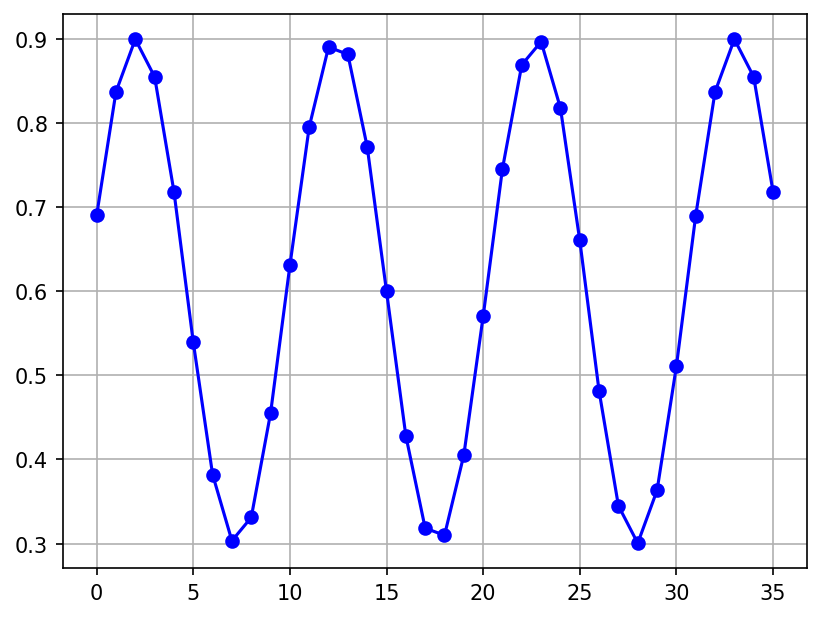

In [73]:
plt.plot(vo[2, :], "b-o")
plt.grid()
plt.show()

In [74]:
hd3_vi = compute_spectra(bins, vi, ndft)[1]
hd3_vo = compute_spectra(bins, vo, ndft)[1]

0.0
-3.633892316718566e-08
2.99158234377024e-09
2.6813832492931837e-08
-1.168131890715929e-06
-6.061518890140626e-07
1.2063517467840807e-06
-5.468650096312993e-08
-6.395295266945567e-07
-2.955795578844597e-08
6.627411228353622e-07
-7.64243615695949e-08
6.278742192209654e-09
3.822856451028113e-06
4.1760787692003505e-06
-3.3130898367872547e-07
1.0596593541947646e-06
2.503607897197206e-08
-1.0818609337499492e-06
-2.6355541018535877e-05
-2.080820779004609e-06
1.3199251735814592e-05
-9.560730384846958e-06
4.879739434555495e-05
-6.895905184198153e-07
8.61277615530096e-07
-2.7030267844987577e-05
-1.2552789745729261e-06
1.4016569601423253e-05
-5.755020253892208e-05


In [75]:
# Analytical data
vov = 0.734
vm = 0.3
fs = 500e6
fin = bins*fs/ndft
c = 1.3e-12
cb = 1e-12
cp =  50e-15
fbw = 4.9e9
hd3_calc = -20*np.log10((1/2)*fin/fbw*(vm/vov)**2 *(cp/cb+0.1)**2)
print(fbw/1e6)

4900.0


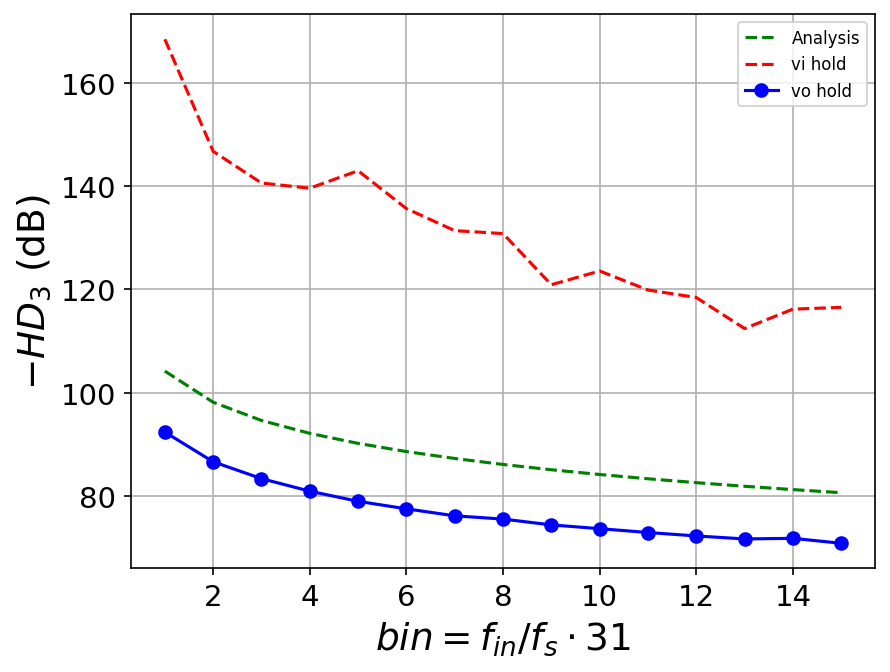

In [76]:
plt.rcParams['figure.dpi'] = 150
plt.plot(bins, hd3_calc, "g--", label='Analysis')
plt.plot(bins, hd3_vi, "r--", label='vi hold')
plt.plot(bins, hd3_vo, "b-o", label='vo hold')
    
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(60, 110)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

-3.3130898367872547e-07
1.0596593541947646e-06
2.503607897197206e-08
-1.0818609337499492e-06
-2.6355541018535877e-05
-2.080820779004609e-06
1.3199251735814592e-05
-9.560730384846958e-06
4.879739434555495e-05
-6.895905184198153e-07
8.61277615530096e-07
-2.7030267844987577e-05
-1.2552789745729261e-06
1.4016569601423253e-05
-5.755020253892208e-05


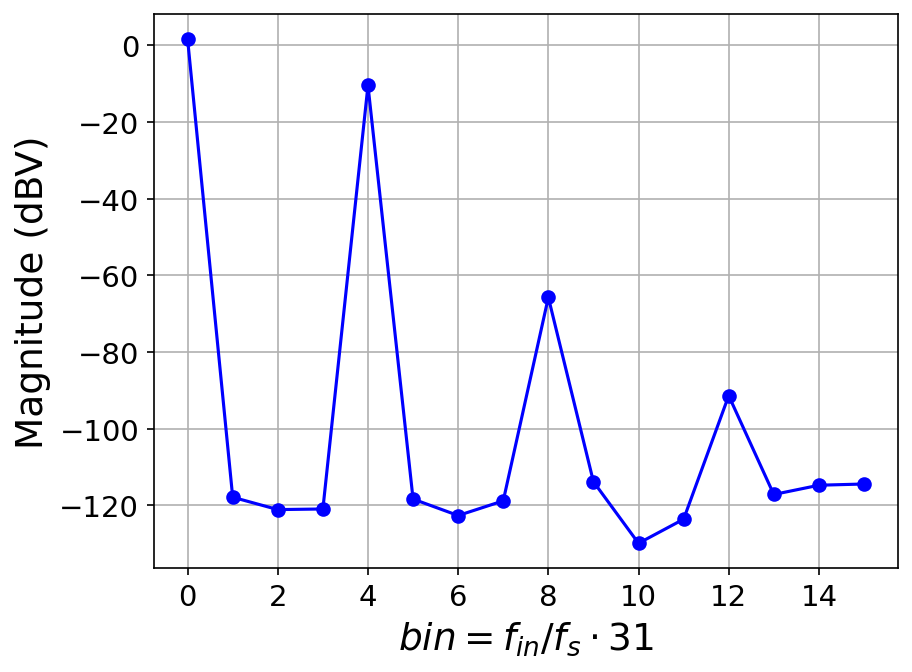

In [77]:
spec_dbv_out = compute_spectra(bins, vo, ndft)[2]

plt.plot(spec_dbv_out[3, :], "b-o")
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("Magnitude (dBV)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.show()
